## Classification of Text Documents using Naive Bayes

In natural language processing and machine learning Naive Bayes is a popular method for classifying text documents. It can be used to classifies documents into pre defined types based on likelihood of a word occurring by using Bayes theorem.
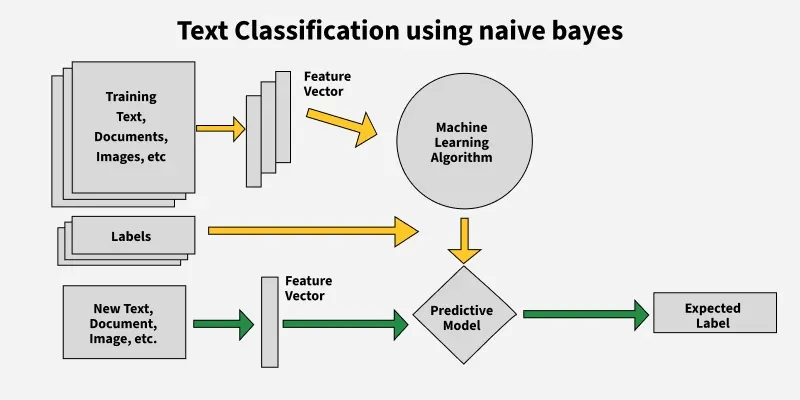

The dataset we will be using will be of text data categorized into four labels: Technology, Sports, Politics and Entertainment.

#### Importing Necessary Libraries

In [27]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

#### Read the Synthetic Dataset

In [43]:
df = pd.read_csv(r'C:\users\hp\downloads\synthetic_text_data.csv')
df

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology
...,...,...
80,AI is enhancing customer experiences in retail...,Technology
81,Politicians are debating the pros and cons of ...,Politics
82,Television networks are trying to adapt to the...,Entertainment
83,New wearable technologies are improving health...,Technology


#### Splitting the dataset into independent and Dependent features.

In [52]:
df.groupby('label').count()

,text
label,
Entertainment,19
Politics,21
Sports,15
Technology,30


In [29]:
X = df['text']
y = df['label']

#### Split the features into training and testing data

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#### Text Preprocessing: Converting Text to Numeric Features

In [31]:
vectorizer = CountVectorizer()
X_trained_vectorized = vectorizer.fit_transform(X_train)
X_test_victorized = vectorizer.transform(X_test)

#### Model Training using MultinomialNB

In [32]:
model = MultinomialNB()
model.fit(X_trained_vectorized, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


#### Making Predictions

In [33]:
y_pred = model.predict(X_test_victorized)

#### Model Evaluation

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

Accuracy 88.23529411764706%


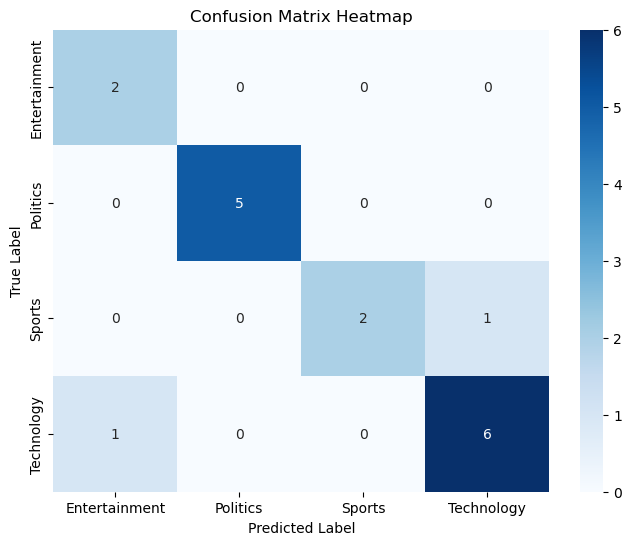

In [35]:
accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test,y_pred)

print(f'Accuracy {accuracy*100}%')

class_labels = np.unique(y_test)

plt.figure(figsize=(8,6))
sns.heatmap(Confusion_Matrix, annot = True, fmt='d',
            cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [48]:
user_input = input()

user_input_vectorized = vectorizer.transform([user_input])
predicted_label = model.predict(user_input_vectorized)
print(f"The input text belongs to the '{predicted_label[0]}' category.")

 Football fans are excited for upcomming tournament


The input text belongs to the 'Sports' category.
